In [71]:
import pandas as pd 
import numpy as np

In [72]:
df=pd.read_csv('apple_stock/AAPL.csv')
print(df.head())
print(df.shape)

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600
(10468, 7)


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB


In [74]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [75]:
df["Date"]=pd.to_datetime(df["Date"])
print(df.dtypes)

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [76]:
high_prices = df["High"].to_numpy()

print(high_prices.shape)
print(high_prices[:10])

(10468,)
[0.128906 0.12221  0.113281 0.116071 0.11942  0.126674 0.132813 0.138393
 0.145647 0.15904 ]


In [77]:
def seq (d,window_size):
    x=[]
    y=[]
    for i in range(len(d)-window_size):
        x.append(d[i:i+window_size])
        y.append(d[i+window_size])
    return np.array(x),np.array(y)

x,y=seq(high_prices,50)

print(x.shape)
print(y.shape)


(10418, 50)
(10418,)


In [78]:
import torch

x_tensor = torch.tensor(x,dtype=torch.float32)

y_tensor = torch.tensor(y,dtype=torch.float32)

print(x_tensor.shape)
print(y_tensor.shape)

print(x_tensor[0])
print(y_tensor[0])

torch.Size([10418, 50])
torch.Size([10418])
tensor([0.1289, 0.1222, 0.1133, 0.1161, 0.1194, 0.1267, 0.1328, 0.1384, 0.1456,
        0.1590, 0.1613, 0.1574, 0.1529, 0.1551, 0.1512, 0.1445, 0.1384, 0.1356,
        0.1429, 0.1423, 0.1367, 0.1373, 0.1406, 0.1390, 0.1473, 0.1429, 0.1462,
        0.1479, 0.1473, 0.1445, 0.1440, 0.1390, 0.1339, 0.1272, 0.1194, 0.1239,
        0.1283, 0.1289, 0.1289, 0.1228, 0.1222, 0.1183, 0.1172, 0.1150, 0.1172,
        0.1228, 0.1150, 0.1088, 0.1105, 0.1071])
tensor(0.1133)


In [79]:
from torch.utils.data import TensorDataset

dataset = TensorDataset(
    x_tensor,
    y_tensor
)

print(len(dataset))

x0,y0 = dataset[0]

print(x0.shape)
print(y0.shape)

10418
torch.Size([50])
torch.Size([])


In [80]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

for x_batch, y_batch in loader:
    
    print(x_batch.shape)
    print(y_batch.shape)

    break

torch.Size([64, 50])
torch.Size([64])


In [81]:
x_batch=x_batch.reshape(x_batch.shape[0],x_batch.shape[1])
print(x_batch.shape)

torch.Size([64, 50])


In [82]:
import torch.nn as nn

model = nn.Linear(
    in_features=50,
    out_features=1
)

print(model)

Linear(in_features=50, out_features=1, bias=True)


In [83]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
criterion = nn.MSELoss()

In [84]:
pred = model(x_batch)
y_batch = y_batch.unsqueeze(1)

loss = criterion(pred, y_batch)

print(model.weight[0][:5])
optimizer.zero_grad()

loss.backward()

optimizer.step()
print(model.weight[0][:5])
print(loss)



tensor([-0.0534, -0.0014,  0.0020,  0.0043,  0.0962], grad_fn=<SliceBackward0>)
tensor([-0.0524, -0.0004,  0.0030,  0.0053,  0.0972], grad_fn=<SliceBackward0>)
tensor(182.7896, grad_fn=<MseLossBackward0>)


In [ ]:
num_epochs = 10
raw_losses = []

for epoch in range(num_epochs):

    epoch_loss = 0

    for x_batch, y_batch in loader:

        x_batch = x_batch.squeeze(-1)
        y_batch = y_batch.unsqueeze(1)

        pred = model(x_batch)

        loss = criterion(pred, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(loader):.4f}")
    raw_losses.append(epoch_loss/len(loader))

Epoch 1, Loss: 11.1749
Epoch 2, Loss: 5.6132
Epoch 3, Loss: 4.8672
Epoch 4, Loss: 3.9276
Epoch 5, Loss: 3.1736
Epoch 6, Loss: 3.0674
Epoch 7, Loss: 2.8093
Epoch 8, Loss: 2.5617
Epoch 9, Loss: 2.3544
Epoch 10, Loss: 2.2420


In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

high_prices_scaled = scaler.fit_transform(high_prices.reshape(-1, 1))



In [ ]:
split_price = int(len(high_prices)*0.8)

train_prices = high_prices[:split_price]
test_prices = high_prices[split_price:]

#scaler = MinMaxScaler()

train_prices_scaled = scaler.fit_transform(train_prices.reshape(-1,1))

test_prices_scaled = scaler.transform(test_prices.reshape(-1,1))

In [88]:
x_train, y_train = seq(train_prices_scaled,50)

x_test, y_test = seq(test_prices_scaled,50)

In [89]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(8324, 50, 1)
(8324, 1)
(2044, 50, 1)
(2044, 1)


In [ ]:
x_train_tensor = torch.tensor(x_train,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train,dtype=torch.float32)

x_test_tensor = torch.tensor(x_test,dtype=torch.float32)

y_test_tensor = torch.tensor(y_test,dtype=torch.float32)

In [91]:
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    x_test_tensor,
    y_test_tensor
)

In [92]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [93]:
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor
)

print(len(train_dataset))

x01,y01 = train_dataset[0]

print(x01.shape)
print(y01.shape)

8324
torch.Size([50, 1])
torch.Size([1])


In [94]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

for x_batch_train, y_batch_train in train_loader:    
    print(x_batch_train.shape)
    print(y_batch_train.shape)

    break

torch.Size([64, 50, 1])
torch.Size([64, 1])


In [95]:
model_linear_scaled = nn.Linear(50,1)

optimizer = optim.Adam(
    model_linear_scaled.parameters(),
    lr=0.001
)

In [ ]:
norm_loss=[]
num_epochs = 10

for epoch in range(num_epochs):

    epoch_loss = 0

    for x_batch_scaled, y_batch_scaled in train_loader :

        x_batch = x_batch_scaled.squeeze(-1)
        y_batch = y_batch_scaled

        pred = model_linear_scaled(x_batch)

        loss = criterion(pred, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.4f}")
    norm_loss.append(epoch_loss/len(train_loader))    

Epoch 1, Loss: 0.0058
Epoch 2, Loss: 0.0003
Epoch 3, Loss: 0.0002
Epoch 4, Loss: 0.0002
Epoch 5, Loss: 0.0002
Epoch 6, Loss: 0.0002
Epoch 7, Loss: 0.0001
Epoch 8, Loss: 0.0001
Epoch 9, Loss: 0.0001
Epoch 10, Loss: 0.0001


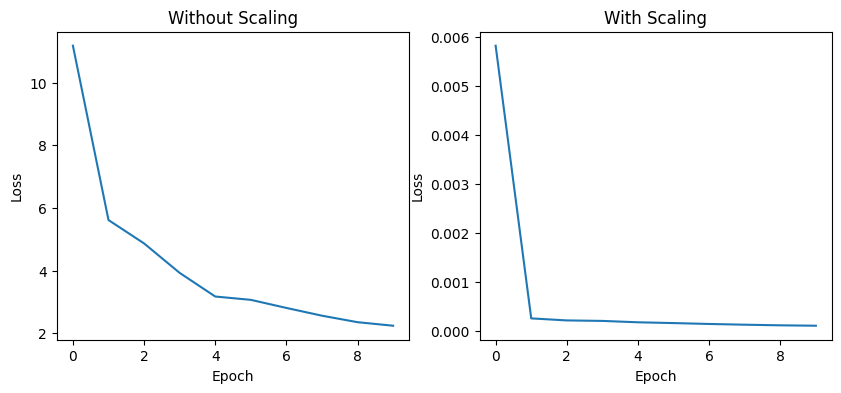

In [97]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(raw_losses)
ax[0].set_title("Without Scaling")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

ax[1].plot(norm_loss)
ax[1].set_title("With Scaling")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")

plt.show()

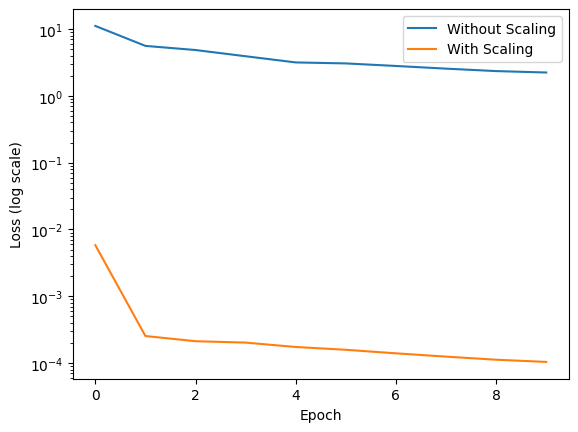

In [98]:
plt.plot(raw_losses, label="Without Scaling")
plt.plot(norm_loss, label="With Scaling")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.show()

In [99]:
class StockLSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,(hn,cn) = self.lstm(x)

        out = hn[-1]

        out = self.fc(out)

        return out

In [100]:
model_lstm = StockLSTM()

optimizer = torch.optim.Adam(
    model_lstm.parameters(),
    lr=0.001
)

for x_batch,y_batch in train_loader:

    pred = model_lstm(x_batch)

    print(pred.shape)
    print(y_batch.shape)

    break

torch.Size([64, 1])
torch.Size([64, 1])


In [ ]:
lstm_losses = []

num_epochs = 50

for epoch in range(num_epochs):

    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        pred = model_lstm(x_batch)

        loss = criterion(pred, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    lstm_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}")

Epoch 1, Loss: 0.009496
Epoch 2, Loss: 0.000145
Epoch 3, Loss: 0.000098
Epoch 4, Loss: 0.000093
Epoch 5, Loss: 0.000077
Epoch 6, Loss: 0.000086
Epoch 7, Loss: 0.000068
Epoch 8, Loss: 0.000062
Epoch 9, Loss: 0.000070
Epoch 10, Loss: 0.000073
Epoch 11, Loss: 0.000060
Epoch 12, Loss: 0.000058
Epoch 13, Loss: 0.000055
Epoch 14, Loss: 0.000051
Epoch 15, Loss: 0.000049
Epoch 16, Loss: 0.000054
Epoch 17, Loss: 0.000046
Epoch 18, Loss: 0.000048
Epoch 19, Loss: 0.000045
Epoch 20, Loss: 0.000047
Epoch 21, Loss: 0.000043
Epoch 22, Loss: 0.000044
Epoch 23, Loss: 0.000045
Epoch 24, Loss: 0.000040
Epoch 25, Loss: 0.000038
Epoch 26, Loss: 0.000036
Epoch 27, Loss: 0.000037
Epoch 28, Loss: 0.000051
Epoch 29, Loss: 0.000038
Epoch 30, Loss: 0.000038
Epoch 31, Loss: 0.000037
Epoch 32, Loss: 0.000032
Epoch 33, Loss: 0.000030
Epoch 34, Loss: 0.000029
Epoch 35, Loss: 0.000032
Epoch 36, Loss: 0.000034
Epoch 37, Loss: 0.000031
Epoch 38, Loss: 0.000027
Epoch 39, Loss: 0.000028
Epoch 40, Loss: 0.000027
Epoch 41,

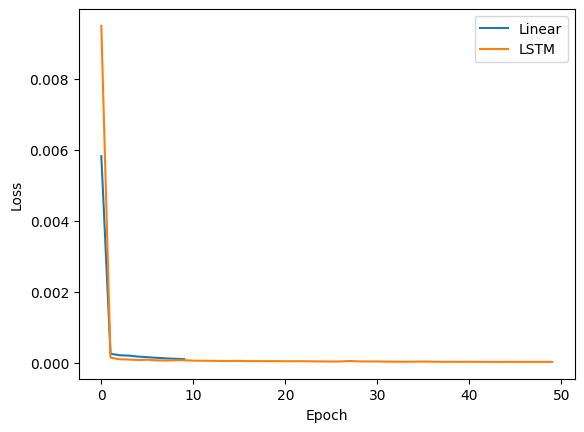

In [102]:
plt.plot(norm_loss,label="Linear")
plt.plot(lstm_losses,label="LSTM")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

evaluation of LSTM

In [103]:
model_lstm.eval()

preds_lstm = []
actuals = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        pred = model_lstm(x_batch)

        preds_lstm.append(pred)

        actuals.append(y_batch)

In [104]:
preds_lstm = torch.cat(preds_lstm)

actuals = torch.cat(actuals)

print(preds_lstm.shape)
print(actuals.shape)

torch.Size([2044, 1])
torch.Size([2044, 1])


In [105]:
pred_prices_lstm = scaler.inverse_transform(
    preds_lstm.numpy()
)

actual_prices = scaler.inverse_transform(
    actuals.numpy()
)

In [106]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae_lstm = mean_absolute_error(
    actual_prices,
    pred_prices_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_prices,
        pred_prices_lstm
    )
)

print("LSTM MAE :", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE : 9.52007007598877
LSTM RMSE: 19.102540235712926


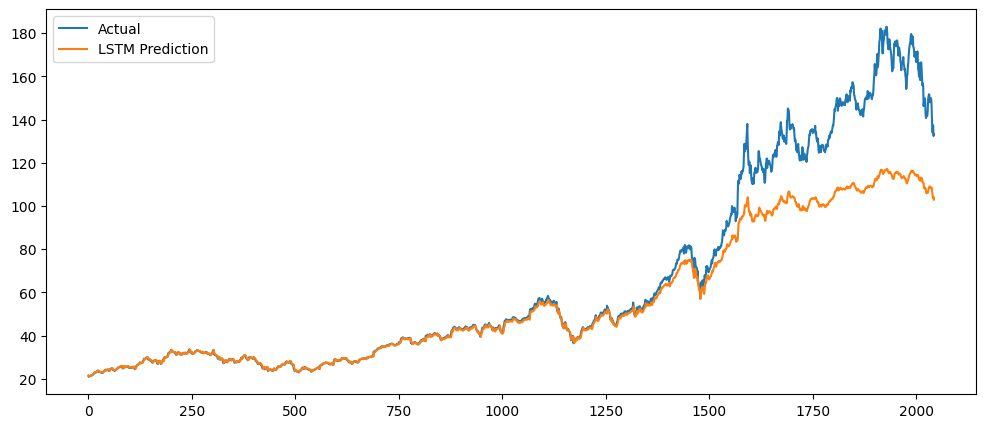

In [107]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_prices,
    label="Actual"
)

plt.plot(
    pred_prices_lstm,
    label="LSTM Prediction"
)

plt.legend()

plt.show()

evaluation of Linear Model 

In [108]:
model_linear_scaled.eval()

preds_linear = []
actuals_linear = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.squeeze(-1)

        pred = model_linear_scaled(x_batch)

        preds_linear.append(pred)

        actuals_linear.append(y_batch)

In [109]:
preds_linear = torch.cat(preds_linear)

actuals_linear = torch.cat(actuals_linear)


pred_prices_linear = scaler.inverse_transform(
    preds_linear.numpy()
)

actual_prices_linear = scaler.inverse_transform(
    actuals_linear.numpy()
)

In [110]:
mae_linear = mean_absolute_error(
    actual_prices_linear,
    pred_prices_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        actual_prices_linear,
        pred_prices_linear
    )
)

print("Linear MAE :", mae_linear)
print("Linear RMSE:", rmse_linear)

Linear MAE : 2.1483452320098877
Linear RMSE: 3.3539020757784703


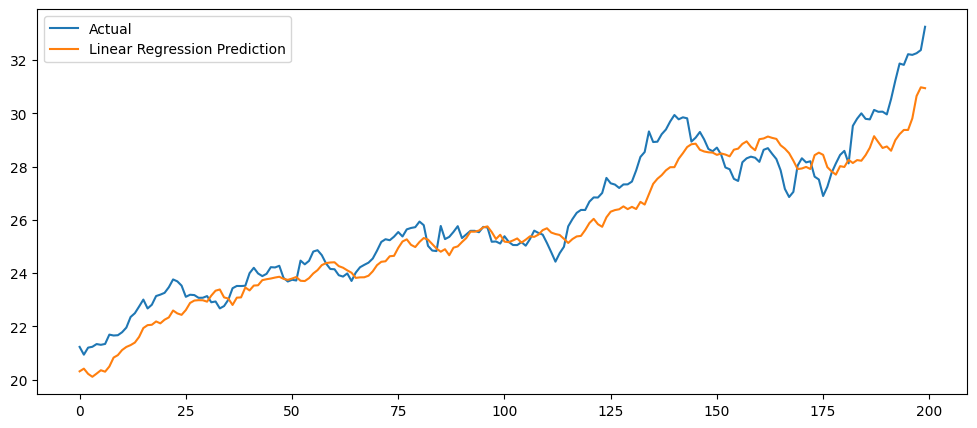

In [111]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_prices_linear[:200],
    label="Actual"
)

plt.plot(
    pred_prices_linear[:200],
    label="Linear Regression Prediction"
)

plt.legend()

plt.show()